# Week 2 Lab — Adult Census Income: EDA & Preprocessing

## 실습 목표
1. UCI Adult (Census Income) 데이터셋을 불러오고 구조를 이해한다.
2. 결측치, 이상치, 분포, 범주형 특성을 EDA로 점검한다.
3. YData Profiling / Sweetviz로 자동 리포트를 생성한다.
4. 결측 대체 + One-hot Encoding 기반 baseline pipeline을 만든다.
5. 과제 1(EDA 리포트)에 바로 활용할 수 있는 인사이트 초안을 만든다.

## 데이터셋 개요
- 데이터셋: UCI Adult (Census Income)
- 행 수: 48,842
- 주요 타깃: `income`
  - `<=50K`
  - `>50K`

## 컬럼 설명
- `age`: 나이
- `workclass`: 고용 형태
- `fnlwgt`: census weight
- `education`: 학력 카테고리
- `education-num`: 학력 수치화
- `marital-status`: 결혼 상태
- `occupation`: 직업
- `relationship`: 가족 관계
- `race`: 인종
- `sex`: 성별
- `capital-gain`: 자본 이득
- `capital-loss`: 자본 손실
- `hours-per-week`: 주당 근무 시간
- `native-country`: 출생 국가
- `income`: 타깃

### `pkg_resources` is deprecated and removed in Python 3.12
### 따라서, 해당 실습코드는 python3.11도 에러가 나고, 아래 링크를 보니 <=3.8 버전에서 성공한다고 함.
https://rec0de.tistory.com/63

In [1]:
# 필요 패키지 설치
# Colab / Jupyter 환경에서 최초 1회만 실행하면 됩니다.
# 일반적인 python 가상환경 세팅 시,
# !pip install ydata-profiling sweetviz missingno ucimlrepo setuptools
# UV 기반 python 가상환경 활용 시,
!uv add ydata-profiling sweetviz missingno ucimlrepo setuptools wheel scikit-learn
!uv sync


Resolved 248 packages in 17ms
Audited 58 packages in 17ms
Resolved 248 packages in 4ms
Audited 146 packages in 17ms


## 1. 데이터 불러오기
- 이번 실습은 `ucimlrepo`를 사용해 UCI Adult 데이터를 직접 불러옵니다.
- Adult 데이터셋은 범주형 + 수치형이 혼합되어 있고,
  일부 컬럼에는 `?` 형태의 결측이 포함되어 있어
  이번 주차 주제(EDA / 결측 / 인코딩)에 매우 적합합니다.

In [11]:
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)

X = adult.data.features.copy()
y = adult.data.targets.copy()

# 타깃 컬럼 결합
df = pd.concat([X, y], axis=1)

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [12]:
# 원본 컬럼 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## 2. 기본 전처리: `?`를 결측치로 변환
Adult 데이터셋은 일부 범주형 컬럼에서 결측이 `?` 문자열로 들어옵니다.
이를 `NaN`으로 바꿔야 결측 분석과 imputing이 자연스럽게 진행됩니다.

In [13]:
# 문자열 '?' 를 NaN으로 변환
df = df.replace("?", np.nan)

# 컬럼명 확인
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [14]:
# 데이터 타입 / 결측 현황 기초 점검
display(df.info())
display(df.isna().mean().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


None

occupation        0.057512
workclass         0.057307
native-country    0.017546
age               0.000000
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
income            0.000000
dtype: float64

## 3. 타깃 분포 확인
이번 데이터셋의 타깃은 `income`이며, 이진 분류 문제입니다.
먼저 클래스 불균형이 어느 정도인지 확인합니다.

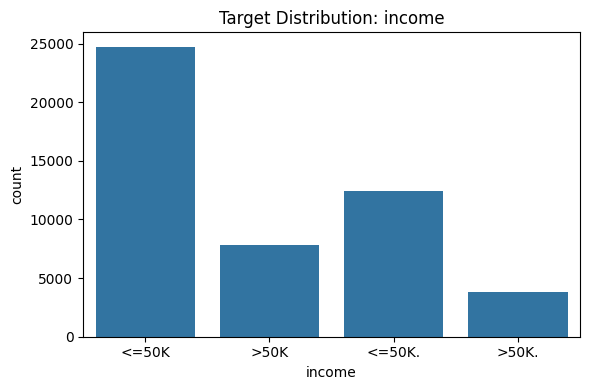

income
<=50K     0.506122
<=50K.    0.254596
>50K      0.160538
>50K.     0.078744
Name: proportion, dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="income")
plt.title("Target Distribution: income")
plt.xlabel("income")
plt.ylabel("count")
plt.tight_layout()
plt.show()

df["income"].value_counts(normalize=True)

## 4. 데이터 타입별 컬럼 분리
EDA와 전처리를 위해 수치형/범주형 컬럼을 먼저 나눕니다.

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


## 5. 기본 요약 통계
수치형 변수의 평균/중앙값/최솟값/최댓값 등을 확인합니다.
특히 `capital-gain`, `capital-loss`는 0이 많고 long-tail일 가능성이 높습니다.

In [17]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


## 6. 결측치 분석
Adult 데이터셋에서 특히 중요한 컬럼:
- `workclass`
- `occupation`
- `native-country`

이 컬럼들은 단순 누락이 아니라 특정 응답 회피/기록 누락일 수도 있습니다.

In [18]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
missing_ratio

occupation        0.057512
workclass         0.057307
native-country    0.017546
age               0.000000
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
income            0.000000
dtype: float64

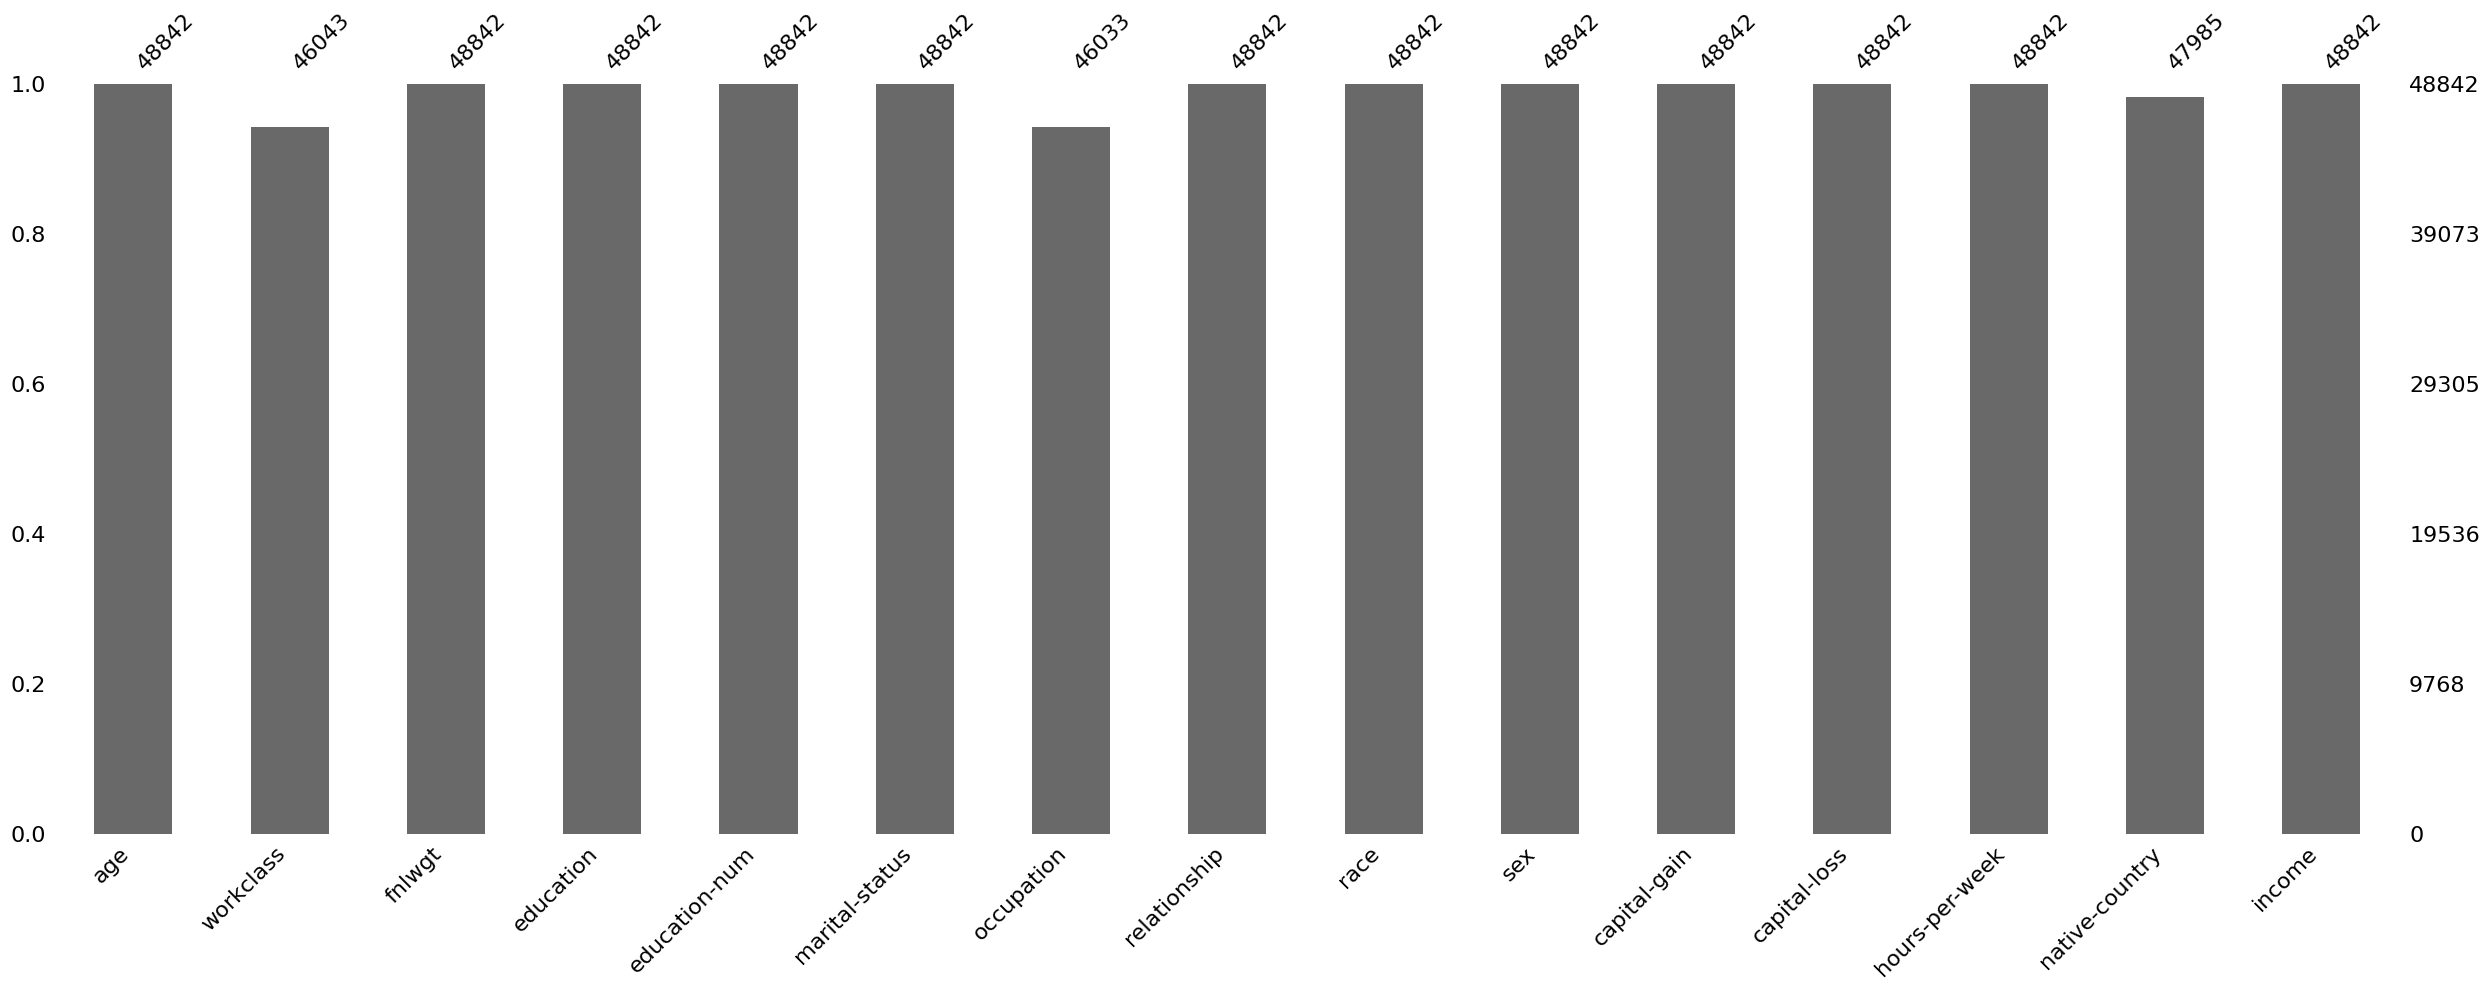

/var/folders/8v/smf6rqys5y98mh5lrlzs0cmw0000gn/T/ipykernel_20402/1948097318.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


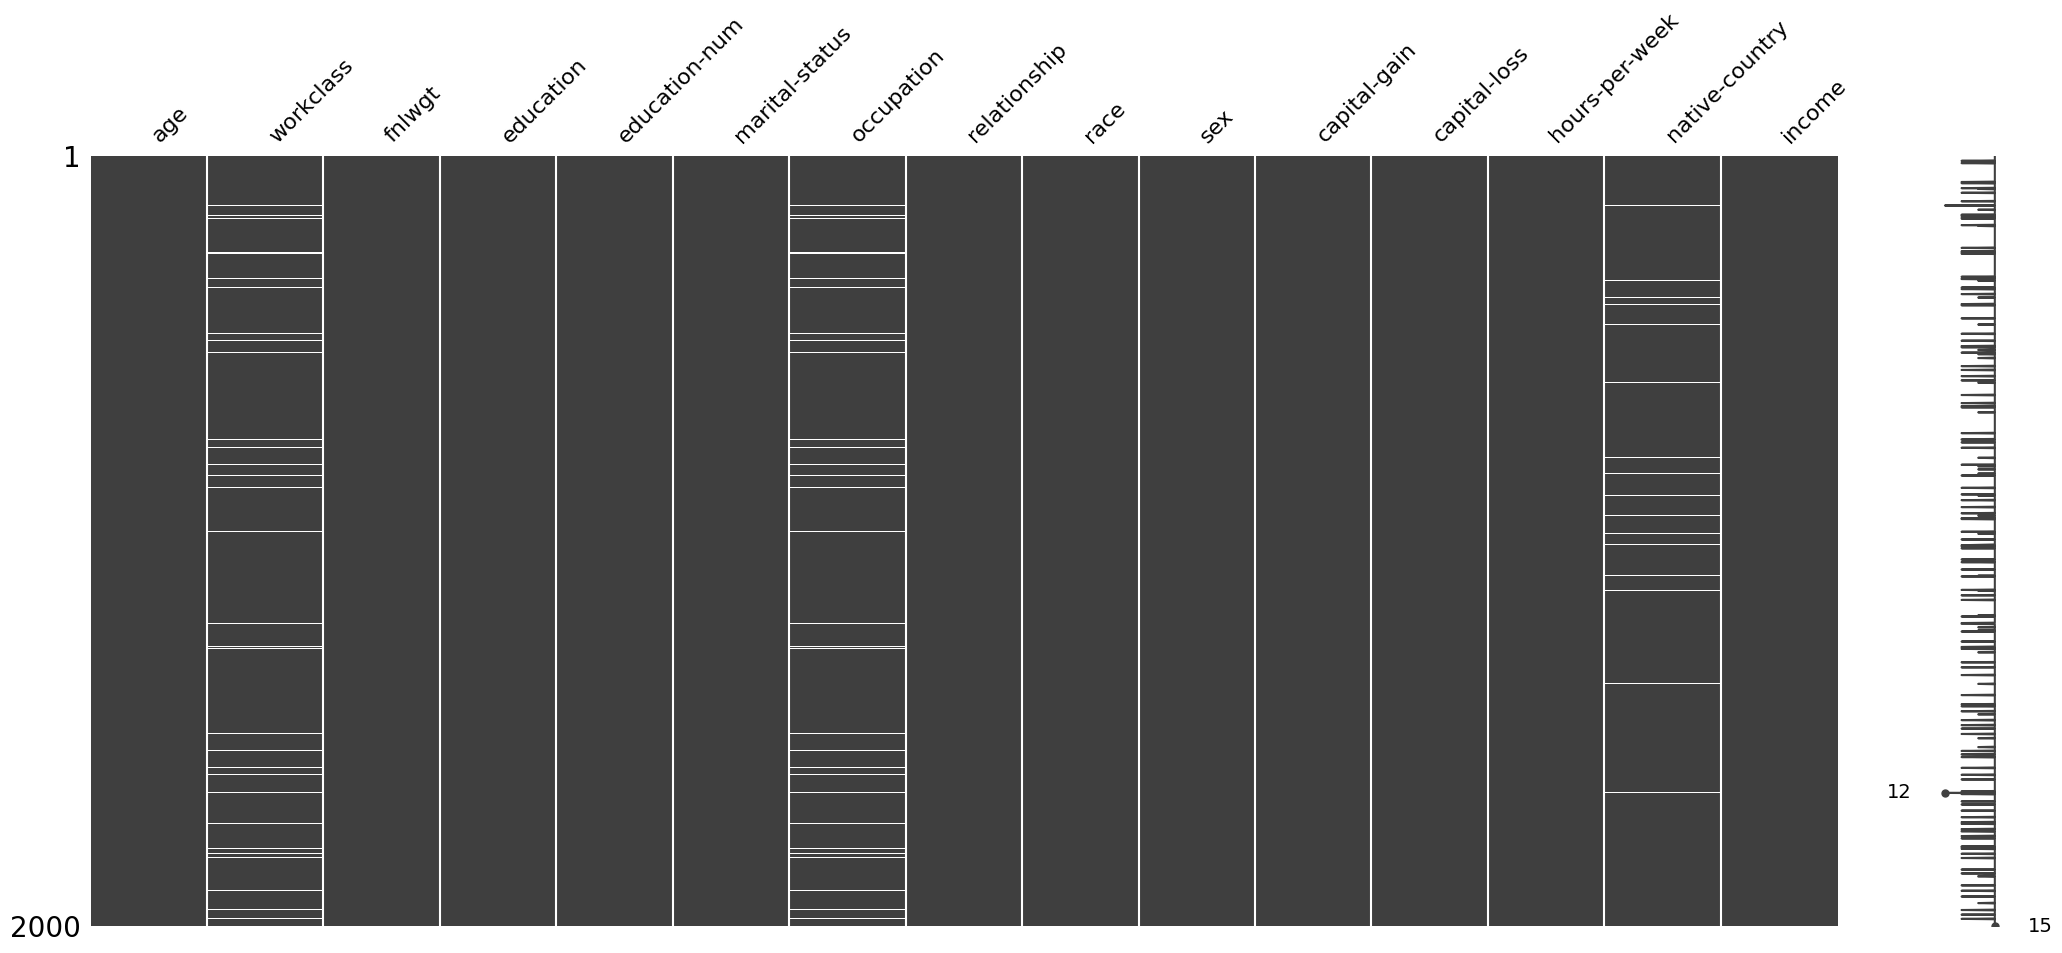

In [19]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
msno.bar(df)
plt.tight_layout()
plt.show()

msno.matrix(df.sample(min(len(df), 2000), random_state=42))
plt.tight_layout()
plt.show()

## 7. 수치형 분포 시각화
이번 실습에서 추천하는 핵심 수치형 변수:
- `age`
- `education-num`
- `hours-per-week`
- `capital-gain`
- `capital-loss`

특히 `capital-gain`, `capital-loss`는 박스플롯과 로그 스케일 관찰이 유용합니다.

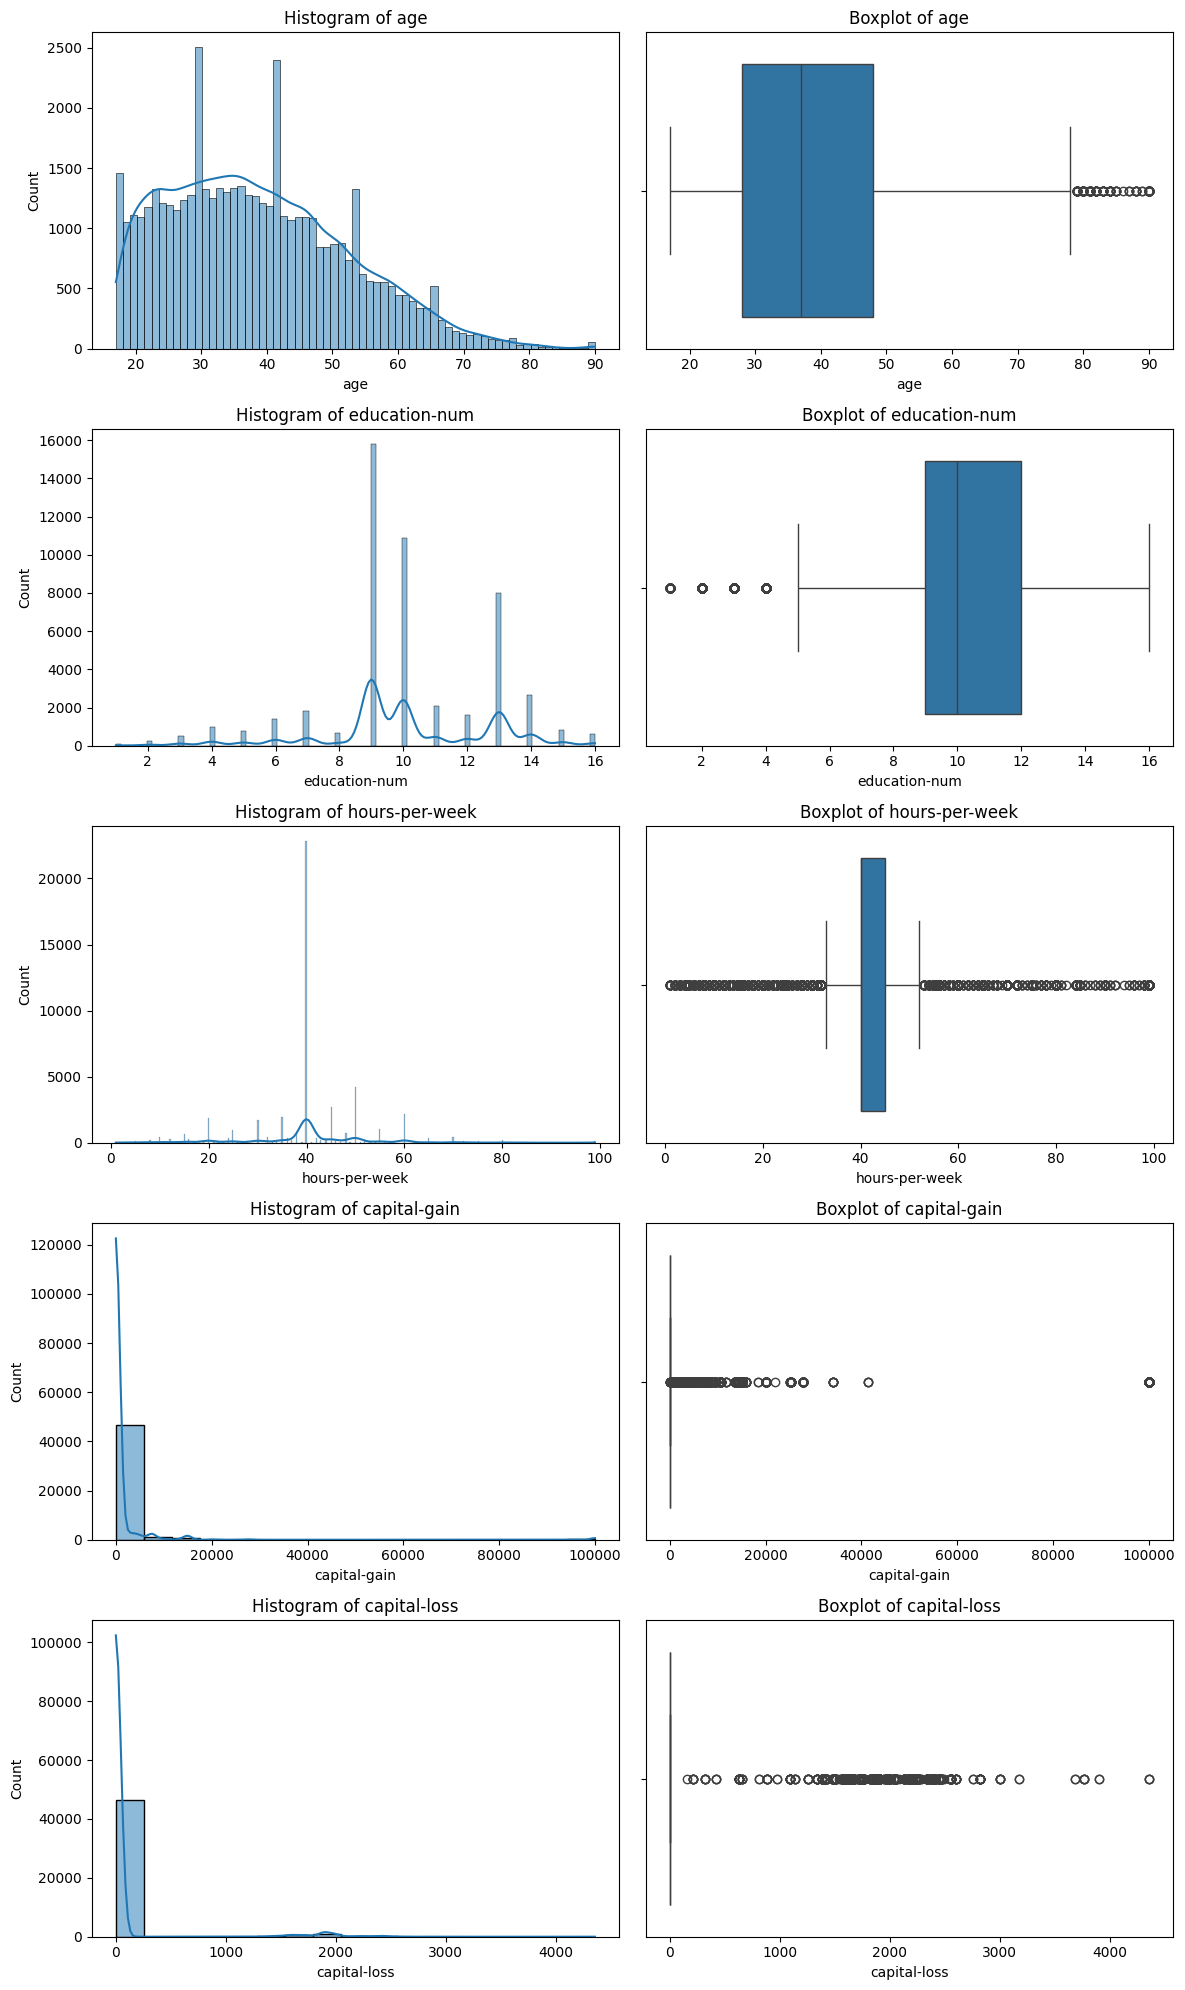

In [20]:
plot_numeric_cols = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]

fig, axes = plt.subplots(len(plot_numeric_cols), 2, figsize=(12, 4*len(plot_numeric_cols)))

for i, col in enumerate(plot_numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogram of {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

## 8. 범주형 빈도 분석
추천 범주형 변수:
- `workclass`
- `education`
- `marital-status`
- `occupation`
- `relationship`
- `sex`

빈도 불균형, 희귀 범주, 표기 구조를 확인합니다.

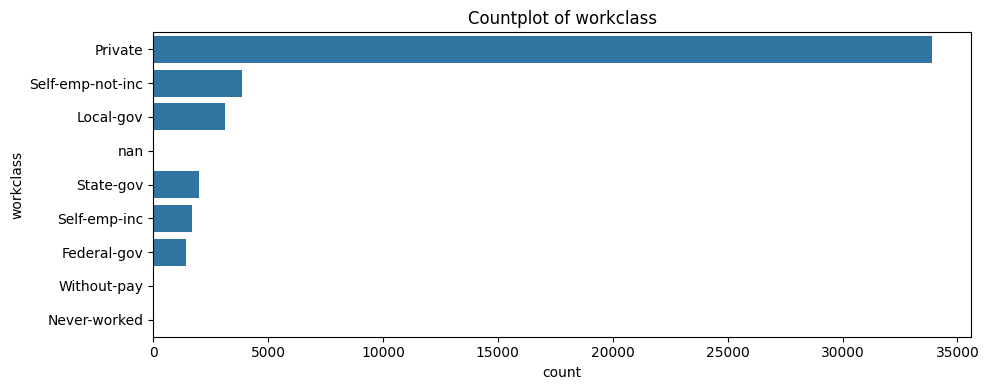

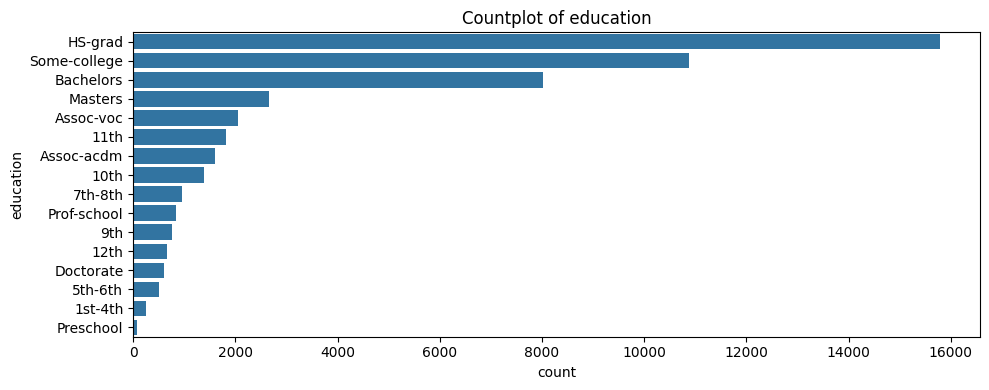

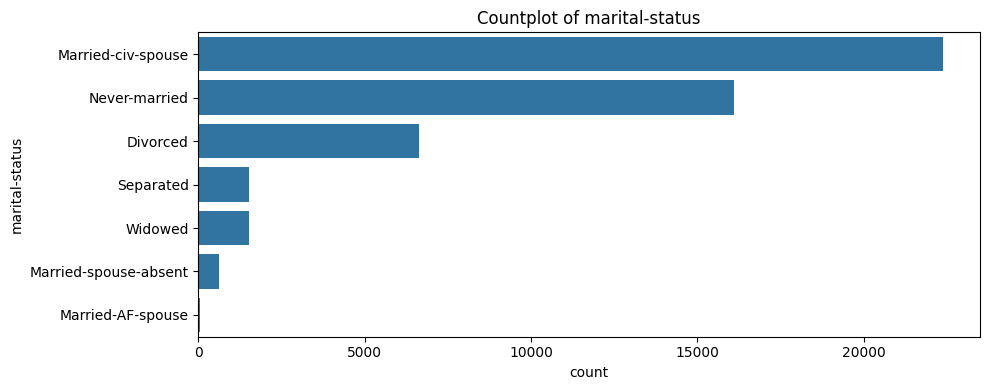

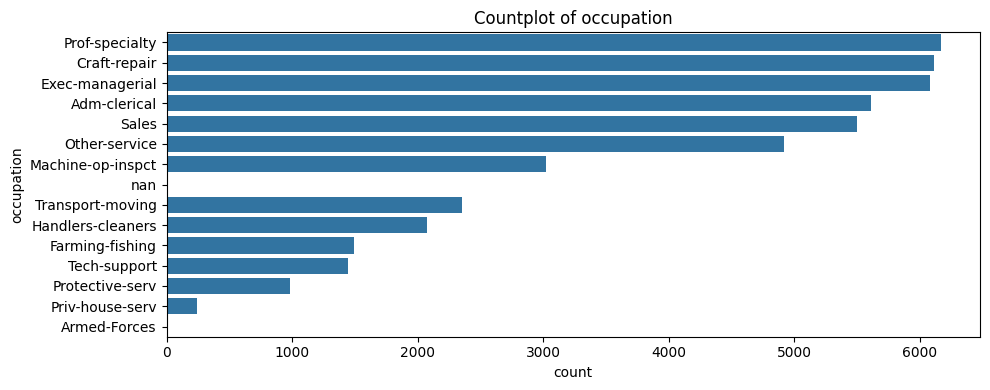

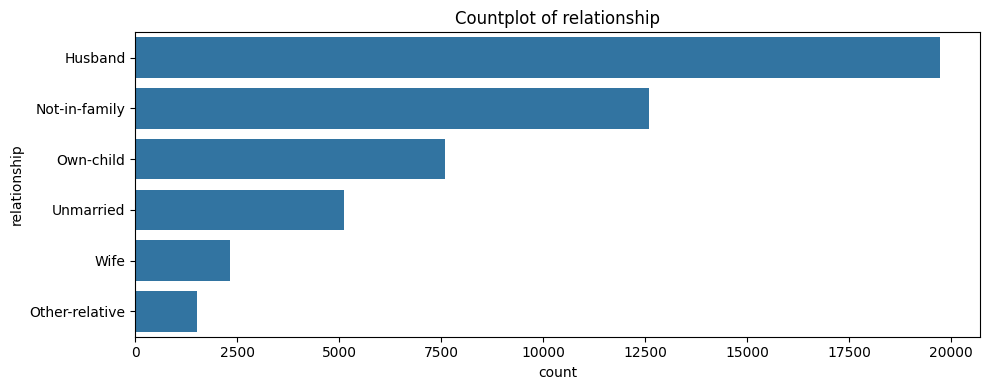

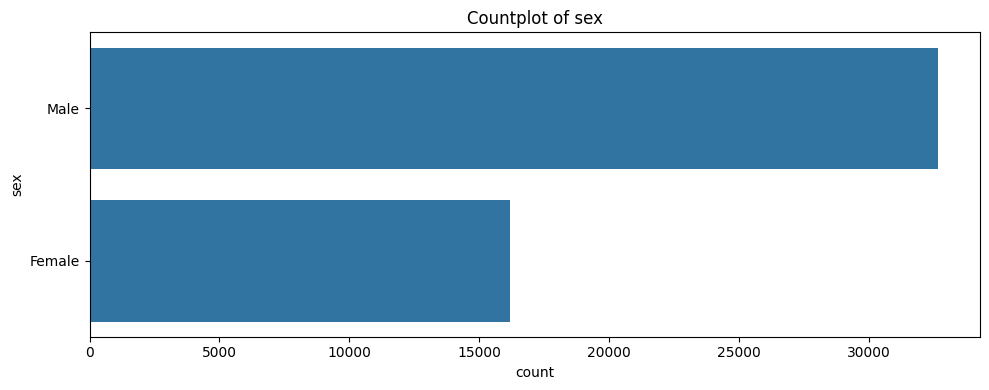

In [21]:
plot_cat_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "sex"]

for col in plot_cat_cols:
    plt.figure(figsize=(10,4))
    order = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, y=col, order=order)
    plt.title(f"Countplot of {col}")
    plt.tight_layout()
    plt.show()

## 9. 타깃과의 관계 분석 (범주형 → income)
범주형 변수별로 `>50K` 비율이 어떻게 달라지는지 보면
EDA 리포트에서 매우 좋은 인사이트를 만들 수 있습니다.

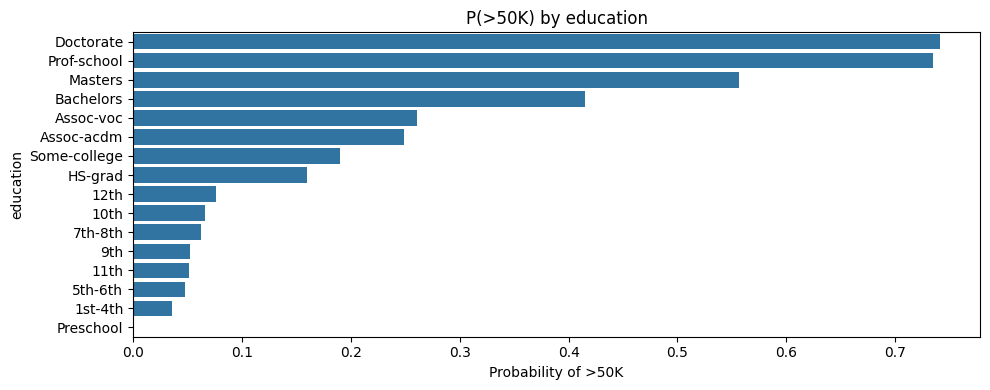

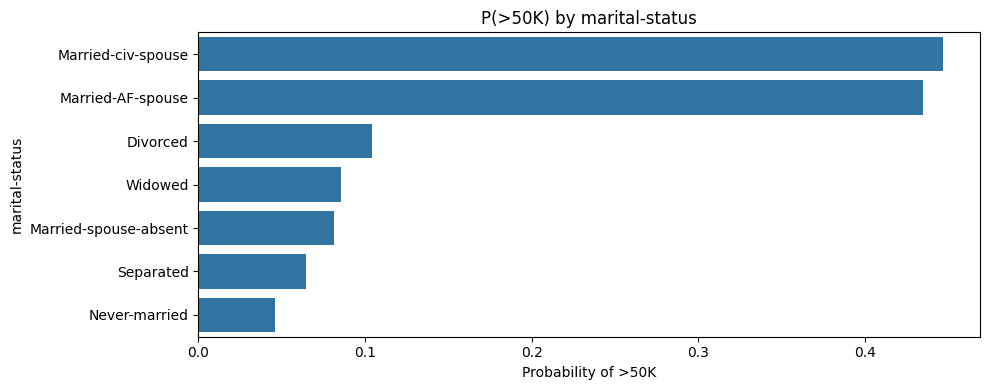

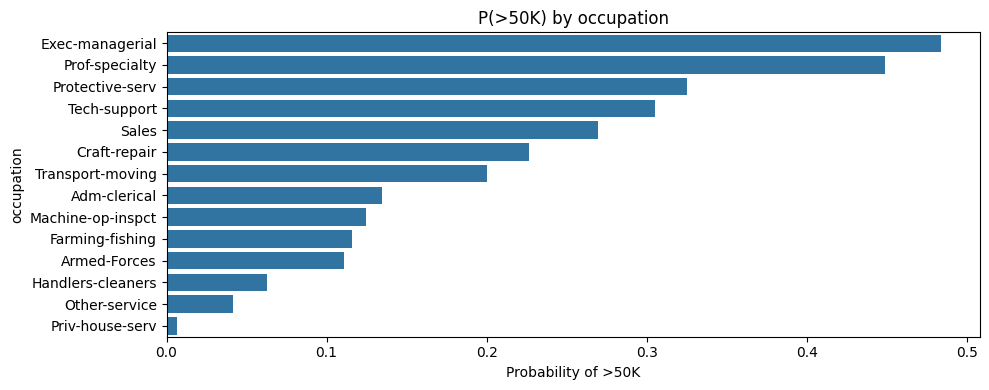

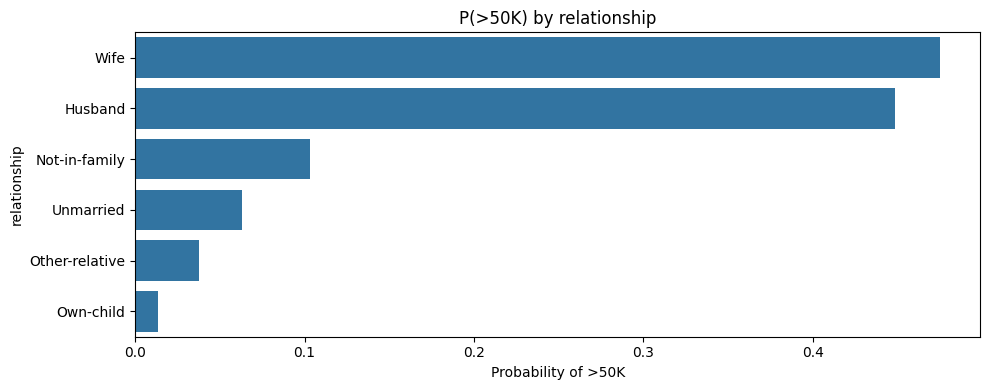

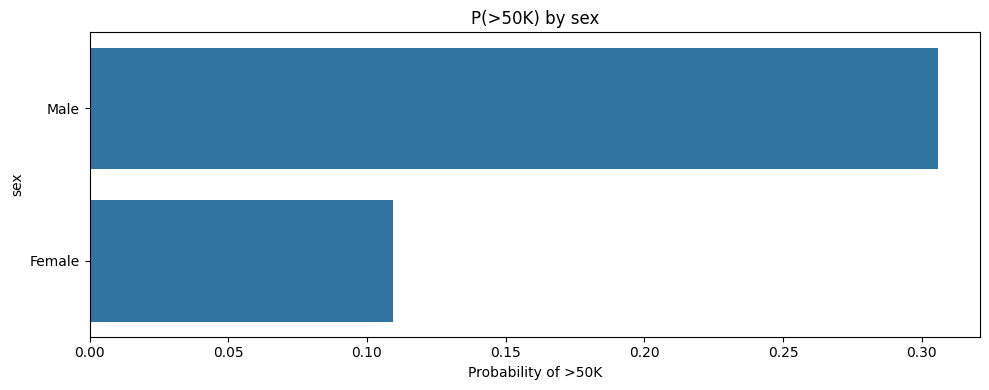

In [22]:
# 타깃을 이진값으로 매핑
df["income_binary"] = df["income"].map({"<=50K": 0, ">50K": 1})

target_cat_cols = ["education", "marital-status", "occupation", "relationship", "sex"]

for col in target_cat_cols:
    temp = df.groupby(col, dropna=False)["income_binary"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    sns.barplot(x=temp.values, y=temp.index)
    plt.title(f"P(>50K) by {col}")
    plt.xlabel("Probability of >50K")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 10. 타깃과의 관계 분석 (수치형 → income)
수치형 변수는 히스토그램을 income별로 나누거나,
박스플롯/바이올린플롯으로 비교하면 좋습니다.

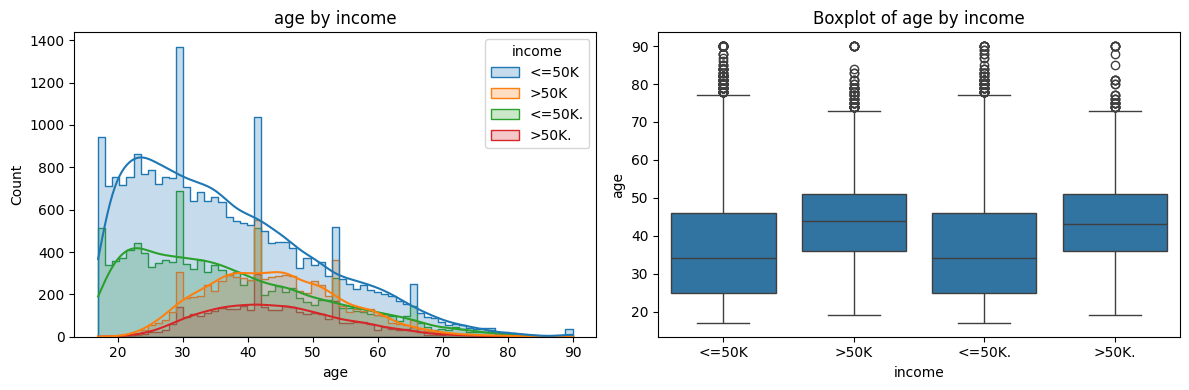

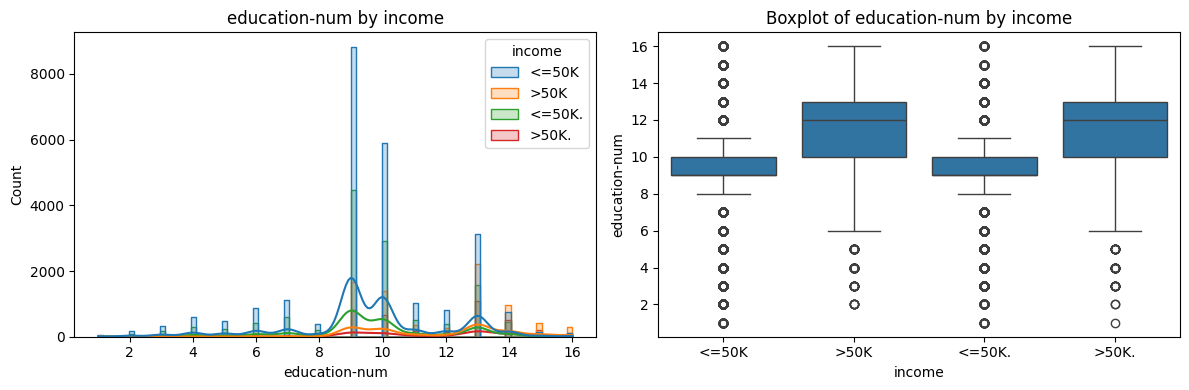

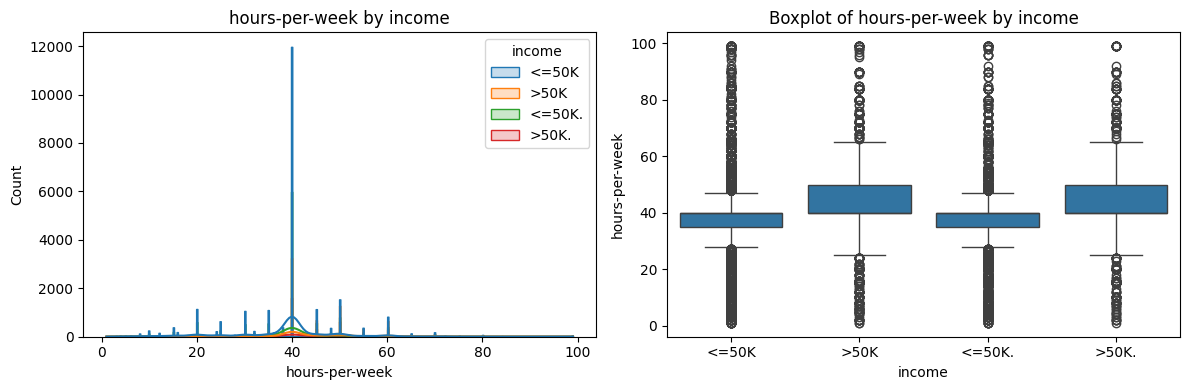

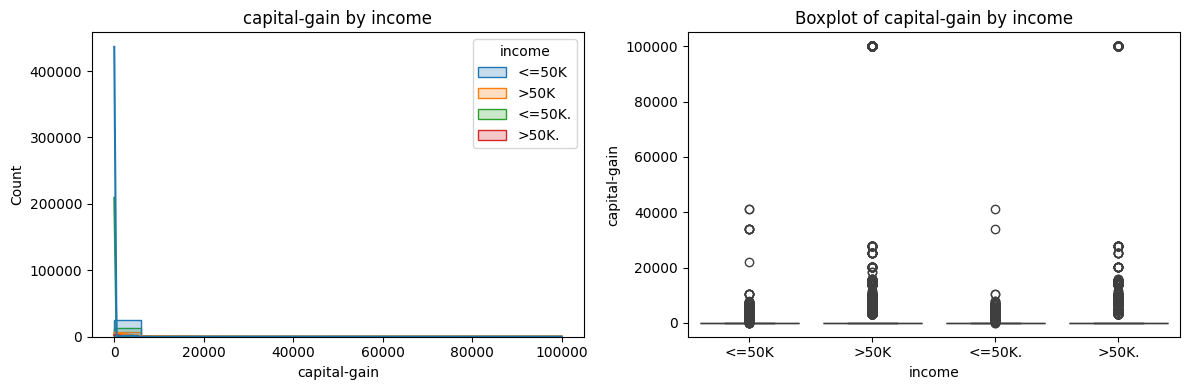

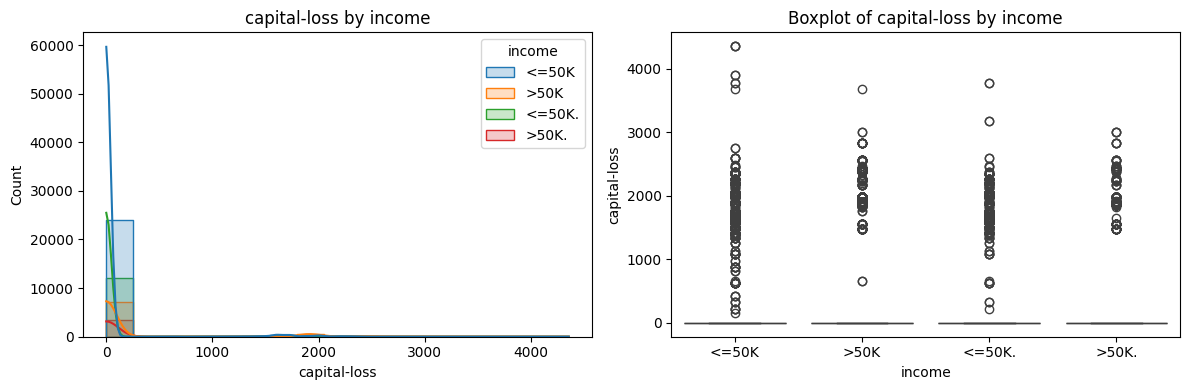

In [23]:
target_num_cols = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]

for col in target_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(data=df, x=col, hue="income", kde=True, element="step", ax=axes[0])
    axes[0].set_title(f"{col} by income")

    sns.boxplot(data=df, x="income", y=col, ax=axes[1])
    axes[1].set_title(f"Boxplot of {col} by income")

    plt.tight_layout()
    plt.show()

## 11. 상관관계 히트맵
수치형 변수들 사이의 상관관계를 확인합니다.
Adult 데이터는 수치형 컬럼 수가 많지 않아서 heatmap이 간결하게 보입니다.

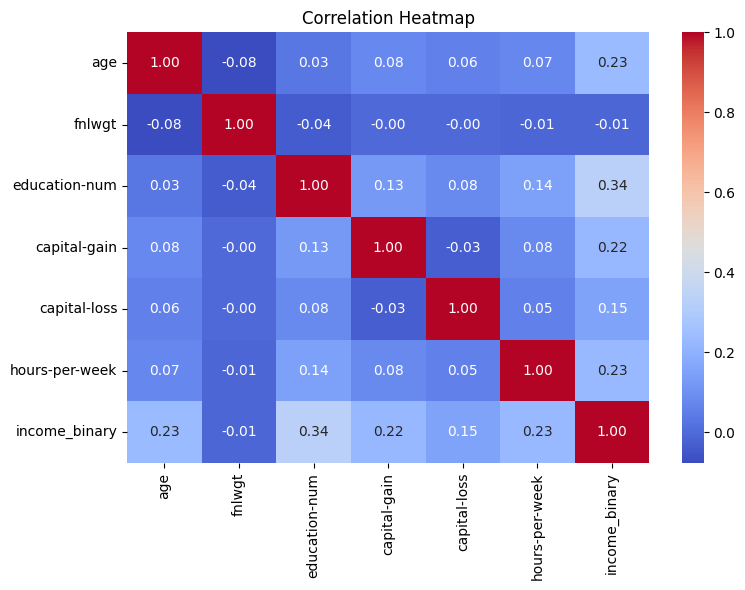

In [24]:
corr = df[numeric_cols + ["income_binary"]].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. 이상치 탐지(IQR 기반)
이상치는 무조건 제거하는 것이 아니라,
오류인지 / 중요한 사건인지 먼저 판단해야 합니다.
여기서는 IQR 기준으로 '후보'만 뽑아봅니다.

In [25]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = []

for col in numeric_cols:
    s = df[col].dropna()
    lo, hi = iqr_bounds(s)
    frac = ((df[col] < lo) | (df[col] > hi)).mean()
    outlier_summary.append((col, frac, lo, hi))

outlier_df = pd.DataFrame(outlier_summary, columns=["column", "outlier_frac", "lower_bound", "upper_bound"])
outlier_df.sort_values("outlier_frac", ascending=False)

,column,outlier_frac,lower_bound,upper_bound
5,hours-per-week,0.276320,32.50,52.50
3,capital-gain,0.082613,0.00,0.00
4,capital-loss,0.046722,0.00,0.00
2,education-num,0.036731,4.50,16.50
1,fnlwgt,0.029749,-62586.75,417779.25
0,age,0.004422,-2.00,78.00


## 13. Automated EDA #1 — YData Profiling
전체 데이터 건강검진용 리포트를 생성합니다.
생성 후 `profile_adult.html` 파일이 저장됩니다.

---

Ydata-profiling python 3.12, 3.13 실습환경에서 둘 다 
ModuleNotFoundError: No module named 'pkg_resources'
에러 이슈로 활용 불가.


In [26]:
# ydata_profiling 문제로 해당 코드 활용하지 않을 예정.
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df.drop(columns=["income_binary"]),
    title="Adult Census Income - YData Profiling Report",
    explorative=True
)

profile.to_file("profile_adult.html")
print("Saved: profile_adult.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 1597.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: profile_adult.html


## 14. Automated EDA #2 — Sweetviz
타깃(`income`) 중심 분석 리포트를 생성합니다.
생성 후 `sweetviz_adult.html` 파일이 저장됩니다.

In [27]:
import sweetviz as sv

# income을 0/1로 변환
df["income_binary"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,   # 혹시 test set 스타일 값이 섞여 있을 경우 대비
    ">50K.": 1
})

# 결측 확인
print(df["income_binary"].value_counts(dropna=False))

# Sweetviz 실행
report = sv.analyze(df.drop(columns=["income"]), target_feat="income_binary")
report.show_html("sweetviz_adult.html", open_browser=False)

print("Saved: sweetviz_adult.html")

income_binary
0    37155
1    11687
Name: count, dtype: int64


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_adult.html was generated.
Saved: sweetviz_adult.html


## 15. 전처리 설계 초안
이제 baseline pipeline을 위해 간단한 전처리 전략을 세웁니다.

### 권장 전략
- 수치형: median imputation
- 범주형: most frequent imputation + one-hot encoding
- 모델: Logistic Regression baseline

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = df.drop(columns=["income", "income_binary"])
y = df["income_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7431
           1       0.71      0.27      0.39      2338

    accuracy                           0.80      9769
   macro avg       0.76      0.62      0.64      9769
weighted avg       0.78      0.80      0.76      9769

ROC-AUC: 0.5804965419527173
Confusion Matrix:
[[7166  265]
 [1704  634]]


## 16. 과제용 인사이트 초안 자동 생성
아래 문장은 리포트 초안으로 바로 활용 가능합니다.
다만, 그대로 제출하지 말고 그래프/근거를 붙여 재작성하세요.

In [29]:
missing_top = df.isna().mean().sort_values(ascending=False).head(5)
outlier_top = outlier_df.sort_values("outlier_frac", ascending=False).head(3)

cat_cardinality = {c: int(df[c].nunique(dropna=True)) for c in categorical_cols if c != "income"}

print("=== INSIGHT DRAFTS ===")
print(f"1) 결측 상위 컬럼은 {list(missing_top.index)}이며, 특히 결측률은 {missing_top.round(3).to_dict()} 로 나타났다.")
print("2) 이상치 후보 비율 상위 수치형 변수는 " +
      ", ".join([f"{r.column}({r.outlier_frac:.2%})" for r in outlier_top.itertuples()]) +
      " 이다.")
print(f"3) 범주형 컬럼의 카디널리티는 {cat_cardinality} 로 확인되며, low-cardinality 변수는 one-hot encoding이 적합하다.")
print("4) education, marital-status, occupation, sex 등은 income과의 관계가 비교적 뚜렷하여 baseline 분류 모델의 주요 후보 피처가 될 수 있다.")
print("5) capital-gain / capital-loss는 0이 매우 많고 long-tail 분포를 가지므로, 평균보다 중앙값/IQR 기준 해석이 더 적절하다.")

=== INSIGHT DRAFTS ===
1) 결측 상위 컬럼은 ['occupation', 'workclass', 'native-country', 'age', 'fnlwgt']이며, 특히 결측률은 {'occupation': 0.058, 'workclass': 0.057, 'native-country': 0.018, 'age': 0.0, 'fnlwgt': 0.0} 로 나타났다.
2) 이상치 후보 비율 상위 수치형 변수는 hours-per-week(27.63%), capital-gain(8.26%), capital-loss(4.67%) 이다.
3) 범주형 컬럼의 카디널리티는 {'workclass': 8, 'education': 16, 'marital-status': 7, 'occupation': 14, 'relationship': 6, 'race': 5, 'sex': 2, 'native-country': 41} 로 확인되며, low-cardinality 변수는 one-hot encoding이 적합하다.
4) education, marital-status, occupation, sex 등은 income과의 관계가 비교적 뚜렷하여 baseline 분류 모델의 주요 후보 피처가 될 수 있다.
5) capital-gain / capital-loss는 0이 매우 많고 long-tail 분포를 가지므로, 평균보다 중앙값/IQR 기준 해석이 더 적절하다.


## 17. 리포트 질문(과제용)
아래 질문에 답하는 형태로 EDA 리포트를 작성하면 좋습니다.

1. 타깃(`income`) 분포는 균형적인가? 모델 평가 시 어떤 점을 주의해야 하는가?
2. 결측이 있는 컬럼(`workclass`, `occupation`, `native-country`)은 왜 비어 있을 가능성이 있는가?
3. 어떤 수치형 변수에서 long-tail / 이상치가 특히 두드러지는가?
4. 어떤 범주형 변수들이 `>50K` 여부와 강한 관계를 보이는가?
5. One-hot encoding이 적합한 컬럼과, 추가 전략(rare category 처리 등)이 필요한 컬럼은 무엇인가?
6. 지금 시점에서 가장 큰 데이터 품질 리스크 1개와, 그 대응 전략은 무엇인가?

## 18. 실습 체크아웃 문장
실습이 끝나면 아래 3문장을 말할 수 있어야 합니다.

- 우리 데이터의 가장 큰 품질 리스크는 ______ 이다.
- 나는 결측치를 ______ 방식으로 처리하겠다.
- 나는 범주형 변수 중 ______ 에 대해 one-hot encoding을 적용하겠다.

이 3문장이 곧 과제 1의 핵심 결론입니다.